# Unit 1 — companion notebook
Code for the worked examples in the [Unit 1 notes](https://elevien.github.io/math50_sandbox/unit1/).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from math import comb

rng = np.random.default_rng(0)

### Example: Bernoulli distribution

In [2]:
def bernoulli_pmf(y, q):
    return q if y == 1 else 1 - q

q = 0.7
print(bernoulli_pmf(0, q), bernoulli_pmf(1, q))

0.30000000000000004 0.7


### Example: a distribution on survey responses

In [3]:
q = 1 / 4  # P(0,0) = P(0,1) = P(1,0) = P(1,1) = q
p_at_least_one_yes = 1 - q  # complement of (0,0)
print(p_at_least_one_yes)

0.75


### Example: gene model

In [4]:
P = {(0, 0): 1/2, (0, 1): 1/8, (1, 0): 1/8, (1, 1): 1/4}
P_A0 = P[(0, 0)] + P[(0, 1)]
P_B0 = P[(0, 0)] + P[(1, 0)]
print("P(Y_A=0) =", P_A0, " P(Y_B=0) =", P_B0)
print("independent would need", P_A0 * P_B0, "== P(Y_A=0,Y_B=0) =", P[(0, 0)])

# conditioning
P_A1_given_B0 = P[(1, 0)] / P_B0
print("P(Y_A=1 | Y_B=0) =", P_A1_given_B0)

P(Y_A=0) = 0.625  P(Y_B=0) = 0.625
independent would need 0.390625 == P(Y_A=0,Y_B=0) = 0.5
P(Y_A=1 | Y_B=0) = 0.2


### Example: calculating probabilities from a specified joint distribution

In [5]:
outcomes = [(0,0,0), (0,0,1), (0,1,0), (0,1,1), (1,0,0), (1,0,1), (1,1,0), (1,1,1)]
probs = [0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2]
joint = dict(zip(outcomes, probs))

P_C1 = sum(p for (a, b, c), p in joint.items() if c == 1)
P_A1 = sum(p for (a, b, c), p in joint.items() if a == 1)
P_A0_B1 = sum(p for (a, b, c), p in joint.items() if a == 0 and b == 1)
P_AeqB = sum(p for (a, b, c), p in joint.items() if a == b)
print("P(C=1) =", P_C1, " P(A=1) =", P_A1, " P(A=0,B=1) =", P_A0_B1, " P(A=B) =", P_AeqB)

# check A, C look independent
P_A1_C1 = sum(p for (a, b, c), p in joint.items() if a == 1 and c == 1)
print("P(A=1,C=1) =", P_A1_C1, " vs P(A=1)P(C=1) =", P_A1 * P_C1)

P(C=1) = 0.6000000000000001  P(A=1) = 0.5  P(A=0,B=1) = 0.2  P(A=B) = 0.6000000000000001
P(A=1,C=1) = 0.30000000000000004  vs P(A=1)P(C=1) = 0.30000000000000004


### Example: Python — sampling and conditional probability from the gene model

In [6]:
# Define probabilities for each (Y_A, Y_B) pair
probs = [1/2, 1/8, 1/8, 1/4]  # (0,0), (0,1), (1,0), (1,1)
pairs = [(0,0), (0,1), (1,0), (1,1)]

# Generate samples
N = 10000
samples = rng.choice(len(pairs), size=N, p=probs)
Y_A = np.array([pairs[i][0] for i in samples])
Y_B = np.array([pairs[i][1] for i in samples])

# Compute conditional probability P(Y_A = 1 | Y_B = 0)
mask = (Y_B == 0)
cond_prob = np.mean(Y_A[mask] == 1)
print("P(Y_A = 1 | Y_B = 0) =", cond_prob)

P(Y_A = 1 | Y_B = 0) = 0.2010886967659302


### Example: conditional Bernoulli model

In [7]:
Py = {0: 1/2, 1: 1/2}
Px_given_y = {(1, 0): 1/4, (0, 0): 3/4, (1, 1): 1/2, (0, 1): 1/2}
joint2 = {(x, y): Px_given_y[(x, y)] * Py[y] for x in (0, 1) for y in (0, 1)}
print(joint2)

{(0, 0): 0.375, (0, 1): 0.25, (1, 0): 0.125, (1, 1): 0.25}


### Example: Python — DataFrame estimate of a conditional probability

In [8]:
# Support and probabilities (match the table above)
outcomes = np.array([
    (0,0,0), (0,0,1), (0,1,0), (0,1,1),
    (1,0,0), (1,0,1), (1,1,0), (1,1,1)
], dtype=int)
probs = np.array([0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2], dtype=float)

# Draw N iid samples
N = 200_000
idx = rng.choice(len(outcomes), size=N, p=probs)
samples = outcomes[idx]

# Build DataFrame with columns A, B, C
df = pd.DataFrame(samples, columns=["A", "B", "C"])

# Estimate P(A=0 | B=1, C=1)
mask = (df["B"]==1) & (df["C"]==1)
est = (df.loc[mask, "A"]==0).mean()
print("Estimated P(A=0 | B=1, C=1):", est)

Estimated P(A=0 | B=1, C=1): 0.3386412952762477


### Example: estimating a coin's bias

Estimated probability: 0.593


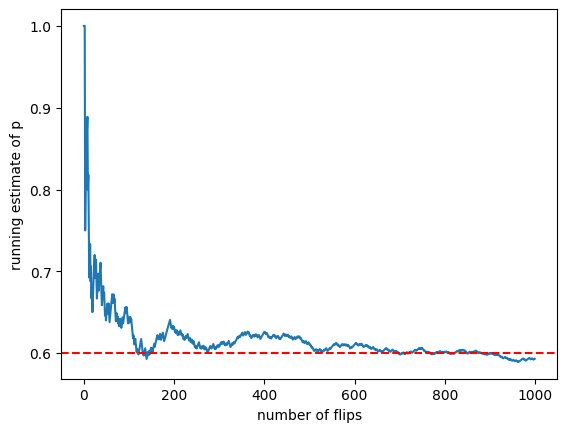

In [9]:
# True probability of YES (e.g. support for a policy)
p_true = 0.6

# Collect 1000 samples (YES=1, NO=0)
n = 1000
flips = rng.binomial(n=1, p=p_true, size=n)
p_hat = flips.mean()
print("Estimated probability:", p_hat)

# running estimate, like the interactive demo in the notes
running = np.cumsum(flips) / np.arange(1, n + 1)
plt.plot(running)
plt.axhline(p_true, color="red", linestyle="--")
plt.xlabel("number of flips")
plt.ylabel("running estimate of p")
plt.show()

### Example: conditioning with continuous random variables

Proportion kept (should be ~0.5): 0.500


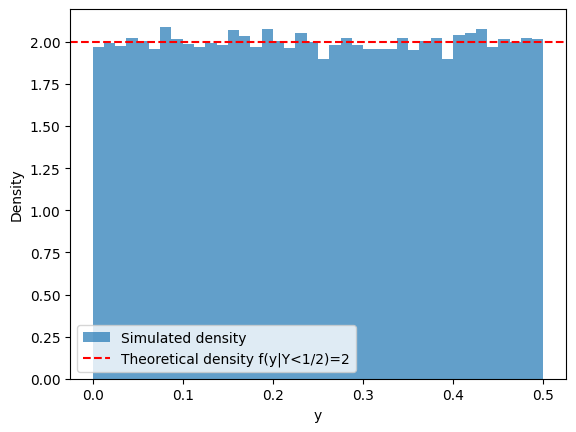

In [10]:
N = 200_000
Y = rng.uniform(0, 1, size=N)
Y_cond = Y[Y < 0.5]

print(f"Proportion kept (should be ~0.5): {len(Y_cond)/N:.3f}")
plt.hist(Y_cond, bins=40, density=True, alpha=0.7, label="Simulated density")
plt.axhline(2.0, color="red", linestyle="--", label="Theoretical density f(y|Y<1/2)=2")
plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.show()

### Example: calculating probabilities (Binomial N=3)

In [11]:
q = 0.4
N = 3
exact = comb(N, 2) * q**2 * (1 - q)
mc = np.mean(rng.binomial(N, q, size=500_000) == 2)
print("Exact P(Y=2) =", exact, " Monte Carlo =", mc)

Exact P(Y=2) = 0.28800000000000003  Monte Carlo = 0.288538


### General Binomial(N,q): Monte Carlo vs. exact PMF

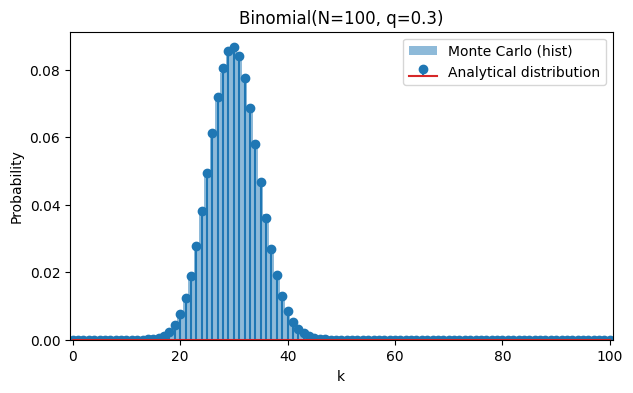

In [12]:
N, q, M = 100, 0.3, 100_000
samples = rng.binomial(n=N, p=q, size=M)

bins = np.arange(-0.5, N + 1.5, 1)
k = np.arange(0, N + 1)
pmf = binom.pmf(k, N, q)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples, bins=bins, density=True, alpha=0.5, label="Monte Carlo (hist)")
ax.stem(k, pmf, label="Analytical distribution")
ax.set_xlabel("k")
ax.set_ylabel("Probability")
ax.set_title(f"Binomial(N={N}, q={q})")
ax.legend()
ax.set_xlim(-0.5, N + 0.5)
plt.show()